In [1]:
import random
from typing import List, Dict, Tuple, Optional

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


COLOR_PALETTE = [
    # Pastel colors
    '#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8',
    '#F7DC6F', '#BB8FCE', '#85C1E2', '#F8B88B', '#A8E6CF',

    # Vivid colors
    '#FF5733', '#33FF57', '#3357FF', '#FF33F5', '#F5FF33',
    '#33FFF5', '#F533FF', '#57FF33', '#5733FF', '#FF3357',

    # Warm tones
    '#FF9999', '#FFCC99', '#FFFF99', '#CCFF99', '#99FF99',
    '#99FFCC', '#99FFFF', '#99CCFF', '#9999FF', '#CC99FF',

    # Cool tones
    '#99CCCC', '#6699CC', '#336699', '#003366', '#006666',
    '#009999', '#00CCCC', '#66CCCC', '#99CCFF', '#CCFFFF',

    # Earth tones
    '#D2691E', '#CD853F', '#DEB887', '#F4A460', '#DAA520',
    '#B8860B', '#BC8F8F', '#CD5C5C', '#F08080', '#FA8072',

    # Neon colors
    '#39FF14', '#DFFF00', '#FFFF00', '#FF6600', '#FF00FF',
    '#00FFFF', '#FF007F', '#7FFF00', '#00FF7F', '#FF1493'
]

def visualize_fer_decomposition(
    grid: np.ndarray,
    result: Dict,
    save_path: Optional[str] = None,
    show: bool = True
):
    rows, cols = grid.shape

    plt.figure(figsize=(7, 7))
    plt.imshow(grid, cmap="gray", origin="upper", extent=[0, cols, rows, 0])

    # Draw rectangles with color palette
    for idx, rect_data in enumerate(result['rectangles']):
        color = COLOR_PALETTE[idx % len(COLOR_PALETTE)]

        plt.gca().add_patch(
            plt.Rectangle(
                (rect_data['min_x'], rect_data['min_y']),
                rect_data['width'],
                rect_data['height'],
                facecolor=color,
                alpha=1,
                edgecolor=color
            )
        )

    plt.axis("off")
    plt.title(f"FER Solution: {len(result['rectangles'])} rectangles")

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)

    if show:
        plt.show()
    else:
        plt.close()


import numpy as np
import matplotlib.pyplot as plt

def visualize_concave_vertices(grid, concave_vertices):
    rows, cols = grid.shape

    # Vytvorenie RGB obrázku (3 kanály)
    image = np.zeros((rows, cols, 3), dtype=np.uint8)

    # Nastavenie pixelov podľa binárnej mriežky
    for i in range(rows):
        for j in range(cols):
            if grid[i, j] == 1:
                image[i, j] = [255, 255, 255]  # biela
            else:
                image[i, j] = [0, 0, 0]  # čierna

    # Označenie vrcholov červenou + číslovanie
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")

    for idx, x, y, corners in concave_vertices:
        if 0 <= y < rows and 0 <= x < cols:
            image[y, x] = [255, 0, 0]

        # vypis do konzoly
        # print(f"{idx}: (x={x}, y={y}) corners={corners}")

        # text do obrázka
        plt.text(
            x,
            y,
            str(idx),
            color="yellow",
            fontsize=10,
            ha="center",
            va="center"
        )

    plt.imshow(image)
    plt.show()

def visualize_concave_vertices_cord(grid, concave_vertices):
    rows, cols = grid.shape

    image = np.zeros((rows, cols, 3), dtype=np.uint8)

    for i in range(rows):
        for j in range(cols):
            if grid[i, j] == 1:
                image[i, j] = [255, 255, 255]
            else:
                image[i, j] = [0, 0, 0]

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")

    # Súradnice každého bieleho pixelu
    for i in range(rows):
        for j in range(cols):
            if grid[i, j] == 1:
                plt.text(
                    j,
                    i,
                    f"({j},{i})",
                    color="gray",
                    fontsize=7,
                    ha="center",
                    va="center",
                    bbox=dict(
                        boxstyle="square,pad=0.1",
                        facecolor="none",
                        edgecolor="gray",
                        linewidth=0.4
                    )
                )

    # Konkávne vrcholy - ID hore, súradnice dole
    for idx, x, y, corners in concave_vertices:
        if 0 <= y < rows and 0 <= x < cols:
            image[y, x] = [255, 0, 0]

        # ID - horná polovica
        plt.text(
            x,
            y - 0.2,
            str(idx),
            color="yellow",
            fontsize=10,
            ha="center",
            va="center",
            fontweight="bold"
        )

        # Súradnice - dolná polovica
        plt.text(
            x,
            y + 0.2,
            f"({x},{y})",
            color="yellow",
            fontsize=7,
            ha="center",
            va="center",
        )

    plt.imshow(image)
    plt.show()

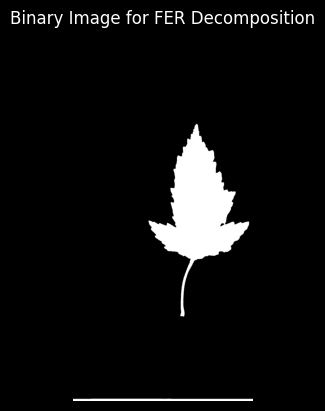

FER ALGORITMUS - LEVEL 1 (MAXIMUM INDEPENDENT SET)

Konkavne vrcholy: 1063
Chords: 282
0: | H | y=643 | x_range=(846, 853) | interior=above | v1=[1](846, 643) v2=[2](853, 643)
1: | H | y=646 | x_range=(843, 854) | interior=above | v1=[4](843, 646) v2=[5](854, 646)
2: | H | y=711 | x_range=(811, 865) | interior=above | v1=[32](811, 711) v2=[33](865, 711)
3: | H | y=723 | x_range=(872, 876) | interior=above | v1=[36](872, 723) v2=[37](876, 723)
4: | H | y=731 | x_range=(808, 881) | interior=above | v1=[42](808, 731) v2=[43](881, 731)
5: | H | y=742 | x_range=(787, 792) | interior=above | v1=[45](787, 742) v2=[46](792, 742)
6: | H | y=744 | x_range=(786, 795) | interior=above | v1=[48](786, 744) v2=[49](795, 744)
7: | H | y=747 | x_range=(785, 800) | interior=above | v1=[52](785, 747) v2=[53](800, 747)
8: | H | y=747 | x_range=(807, 883) | interior=above | v1=[54](807, 747) v2=[55](883, 747)
9: | H | y=764 | x_range=(893, 898) | interior=above | v1=[57](893, 764) v2=[58](898, 764)
10: | H

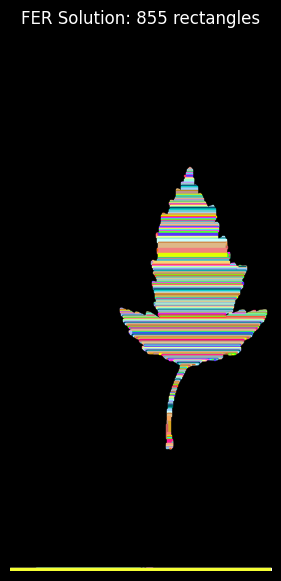

In [2]:
"""Graph-based (FER) algorithm for binary image rectangle decomposition."""

import numpy as np
from collections import defaultdict, deque
import matplotlib.pyplot as plt
from collections import defaultdict



def find_concave_vertices(grid):

    rows, cols = grid.shape
    concave = []

    for y in range(rows - 1):
        for x in range(cols - 1):
            block = grid[y:y+2, x:x+2]
            if block.sum() == 3:
                # Concave corner - corner of block
                concave.append((x, y))

    return concave


def find_concave_corners(grid):
    rows, cols = grid.shape
    concave_points = []
    idx = 0

    for y in range(rows):
        for x in range(cols):
            if grid[y, x] == 1:
                # Bezpečné čítanie susedov s boundary check (0 ak mimo)
                def g(dy, dx):
                    ny, nx = y + dy, x + dx
                    if 0 <= ny < rows and 0 <= nx < cols:
                        return grid[ny, nx]
                    return 0

                t, b = g(-1, 0), g(1, 0)
                l, r = g(0, -1), g(0, 1)
                tl, tr = g(-1, -1), g(-1, 1)
                bl, br = g(1, -1), g(1, 1)

                corners = []
                if t == 1 and l == 1 and tl == 0:
                    corners.append("bottom-right")
                if t == 1 and r == 1 and tr == 0:
                    corners.append("bottom-left")
                if b == 1 and r == 1 and br == 0:
                    corners.append("top-left")
                if b == 1 and l == 1 and bl == 0:
                    corners.append("top-right")

                if corners:
                    concave_points.append((idx, x, y, corners))
                    idx += 1

    return concave_points


def find_cogrid_pairs(concave_vertices, grid):
    rows, cols = grid.shape
    chords = []
    chord_id = 0

    # concave_vertices: list of (id, x, y, corners)

    def chord_lies_inside(positions, axis, fixed):
        if axis == "horizontal":
            y = fixed
            return all(grid[y, x] == 1 for x in positions)
        else:
            x = fixed
            return all(grid[y, x] == 1 for y in positions)

    def interior_side_horizontal(corners):
        sides = set()
        for c in corners:
            if "bottom" in c:
                sides.add("above")
            if "top" in c:
                sides.add("below")
        return sides

    def interior_side_vertical(corners):
        sides = set()
        for c in corners:
            if "right" in c:
                sides.add("left")
            if "left" in c:
                sides.add("right")
        return sides

    def has_interior_on_side_horizontal(y, x_min, x_max, side):
        if side == "above":
            if y <= 0:
                return False
            return all(grid[y - 1, x] == 1 for x in range(x_min, x_max + 1))
        else:  # below
            if y >= rows - 1:
                return False
            return all(grid[y + 1, x] == 1 for x in range(x_min, x_max + 1))

    def has_interior_on_side_vertical(x, y_min, y_max, side):
        if side == "left":
            if x <= 0:
                return False
            return all(grid[y, x - 1] == 1 for y in range(y_min, y_max + 1))
        else:  # right
            if x >= cols - 1:
                return False
            return all(grid[y, x + 1] == 1 for y in range(y_min, y_max + 1))

    # --- Horizontálne chordy ---
    y_groups = defaultdict(list)
    for (vid, x, y, corners) in concave_vertices:
        y_groups[y].append((vid, x, y, corners))

    for y, vertices in y_groups.items():
        vertices = sorted(vertices, key=lambda v: v[1])  # sort by x

        for i in range(len(vertices) - 1):
            v1 = vertices[i]
            v2 = vertices[i + 1]
            _, x1, _, corners1 = v1
            _, x2, _, corners2 = v2

            x_min, x_max = min(x1, x2), max(x1, x2)
            if x_max - x_min < 1:
                continue

            # chord musí ležať celý vo vnútri
            if not chord_lies_inside(range(x_min, x_max + 1), "horizontal", y):
                continue

            # oba vrcholy musia mať spoločnú stranu interiéru
            sides1 = interior_side_horizontal(corners1)
            sides2 = interior_side_horizontal(corners2)
            common_sides = sides1 & sides2

            if not common_sides:
                continue

            # overíme že na spoločnej strane je skutočne súvislý interiér
            valid_side = None
            for side in common_sides:
                if has_interior_on_side_horizontal(y, x_min, x_max, side):
                    valid_side = side
                    break

            if valid_side is None:
                continue

            chords.append({
                "id": chord_id,
                "type": "horizontal",
                "v1": (x1, y),
                "v2": (x2, y),
                "v1_id": vertices[i][0],    # vid
                "v2_id": vertices[i+1][0],  # vid
                "y": y,
                "x_range": (x_min, x_max),
                "interior_side": valid_side
            })
            chord_id += 1

    # --- Vertikálne chordy ---
    x_groups = defaultdict(list)
    for (vid, x, y, corners) in concave_vertices:
        x_groups[x].append((vid, x, y, corners))

    for x, vertices in x_groups.items():
        vertices = sorted(vertices, key=lambda v: v[2])  # sort by y

        for i in range(len(vertices) - 1):
            v1 = vertices[i]
            v2 = vertices[i + 1]
            _, _, y1, corners1 = v1
            _, _, y2, corners2 = v2

            y_min, y_max = min(y1, y2), max(y1, y2)
            if y_max - y_min < 1:
                continue

            # chord musí ležať celý vo vnútri
            if not chord_lies_inside(range(y_min, y_max + 1), "vertical", x):
                continue

            # oba vrcholy musia mať spoločnú stranu interiéru
            sides1 = interior_side_vertical(corners1)
            sides2 = interior_side_vertical(corners2)
            common_sides = sides1 & sides2

            if not common_sides:
                continue

            # overíme že na spoločnej strane je skutočne súvislý interiér
            valid_side = None
            for side in common_sides:
                if has_interior_on_side_vertical(x, y_min, y_max, side):
                    valid_side = side
                    break

            if valid_side is None:
                continue

            chords.append({
                "id": chord_id,
                "type": "vertical",
                "v1": (x, y1),
                "v2": (x, y2),
                "v1_id": vertices[i][0],    # vid
                "v2_id": vertices[i+1][0],  # vid
                "x": x,
                "y_range": (y_min, y_max),
                "interior_side": valid_side
            })
            chord_id += 1

    return chords



def chords_intersect(c1, c2):
    if c1["type"] == c2["type"]:
        return False

    if c1["type"] == "horizontal" and c2["type"] == "vertical":
        h, v = c1, c2
    else:
        h, v = c2, c1

    h_x_min, h_x_max = h["x_range"]
    v_y_min, v_y_max = v["y_range"]

    return (h_x_min <= v["x"] <= h_x_max) and (v_y_min <= h["y"] <= v_y_max)


def build_conflict_graph(chords, grid):
    graph = defaultdict(list)

    for i, chord1 in enumerate(chords):
        for j, chord2 in enumerate(chords):
            if i != j and chords_intersect(chord1, chord2):
                graph[chord1['id']].append(chord2['id'])

    return graph


def is_bipartite_graph(chords, graph):
    return True


def maximum_matching_bipartite(chords, graph):
    horizontal = [c for c in chords if c['type'] == 'horizontal']

    # match_v[v_id] = h_id ktorý je spárovaný s týmto V chordom
    match_v = {}

    def dfs(h_id, visited):
        for v_id in graph[h_id]:
            if v_id in visited:
                continue
            visited.add(v_id)
            if v_id not in match_v or dfs(match_v[v_id], visited):
                match_v[v_id] = h_id
                return True
        return False

    for h_chord in horizontal:
        dfs(h_chord['id'], set())

    matched_pairs = set()
    for v_id, h_id in match_v.items():
        matched_pairs.add(tuple(sorted([h_id, v_id])))

    return matched_pairs


def is_chord_on_boundary(chord, grid):
    rows, cols = grid.shape

    if chord['type'] == 'horizontal':
        y = chord['y']
        x_min, x_max = chord['x_range']

        above_empty = all(grid[y-1, x] == 0 for x in range(x_min, x_max + 1) if y > 0)
        below_empty = all(grid[y+1, x] == 0 for x in range(x_min, x_max + 1) if y < rows - 1)

        return above_empty or below_empty

    else:  # vertical
        x = chord['x']
        y_min, y_max = chord['y_range']

        left_empty = all(grid[y, x-1] == 0 for y in range(y_min, y_max + 1) if x > 0)
        right_empty = all(grid[y, x+1] == 0 for y in range(y_min, y_max + 1) if x < cols - 1)

        return left_empty or right_empty


def maximum_independent_set(chords, graph, matching_pairs):

    # Množina všetkých chord IDs
    all_chord_ids = {c['id'] for c in chords}

    # Chord IDs, ktoré sú v matchingu
    matched_chord_ids = set()
    for pair in matching_pairs:
        matched_chord_ids.add(pair[0])
        matched_chord_ids.add(pair[1])

    # Izolované vrcholy (bez hran v grafe)
    isolated = set()
    for chord in chords:
        if len(graph[chord['id']]) == 0:
            isolated.add(chord['id'])

    # Vrcholy, ktoré nie sú v matchingu
    unmatched = all_chord_ids - matched_chord_ids

    # MIS: vyberieme jeden z každého páru + izolované + nezávislé unmatched
    mis = set()

    # 1. Izolované vrcholy (vždy ich pridáme - žiadne konflikty)
    mis.update(isolated)

    # 2. Jeden z každého matchovaného páru
    # Deterministicky vyberieme prvý z páru (pár je už sorted tuple)
    for pair in matching_pairs:
        mis.add(pair[0])

    # 3. Unmatched vrcholy, ktoré sú nezávislé od už vybraných
    for chord_id in unmatched:
        # Skontrolujeme, či je nezávislý od všetkých už vybraných
        is_independent = True
        for selected_id in mis:
            if selected_id in graph[chord_id]:
                is_independent = False
                break

        if is_independent:
            mis.add(chord_id)

    return mis


def fer_algorithm_level1(concave_vertices, grid, verbose=False):
    if verbose:
        print("=" * 70)
        print("FER ALGORITMUS - LEVEL 1 (MAXIMUM INDEPENDENT SET)")
        print("=" * 70)

    chords = find_cogrid_pairs(concave_vertices, grid)

    if verbose:
        print(f"\nKonkavne vrcholy: {len(concave_vertices)}")
        print(f"Chords: {len(chords)}")
        for chord in chords:
            if chord["type"] == "horizontal":
                print(f"{chord['id']}: | H | y={chord['y']} | x_range={chord['x_range']} | interior={chord['interior_side']} | v1=[{chord['v1_id']}]{chord['v1']} v2=[{chord['v2_id']}]{chord['v2']}")
            else:
                print(f"{chord['id']}: | V | x={chord['x']} | y_range={chord['y_range']} | interior={chord['interior_side']} | v1=[{chord['v1_id']}]{chord['v1']} v2=[{chord['v2_id']}]{chord['v2']}")


    graph = build_conflict_graph(chords, grid)
    is_bip = is_bipartite_graph(chords, graph)
    matching_pairs = maximum_matching_bipartite(chords, graph)

    if verbose:
        print(f"Maximalne parovanie: {len(matching_pairs)}")

    mis = maximum_independent_set(chords, graph, matching_pairs)
    selected_chords = [c for c in chords if c['id'] in mis]

    if verbose:
        print(f"Maximalna nezavisla mnozina (MIS): {len(mis)} chord")

    used_vertices = set()
    for chord in selected_chords:
        used_vertices.add(chord['v1_id'])
        used_vertices.add(chord['v2_id'])

    remaining_vertices = [v for v in concave_vertices if v[0] not in used_vertices]

    if verbose:
        print(f"Zvysne vrcholy pre Level 2: {len(remaining_vertices)}")
        print(f"Level 1 dokonceny: {len(selected_chords)} rezov z MIS")

    return selected_chords, remaining_vertices


def fer_algorithm_level2(remaining_vertices, grid, level1_cuts, verbose=False):

    if verbose:
        print("\n" + "=" * 70)
        print("FER ALGORITHM - LEVEL 2 (NEAREST EDGE)")
        print("=" * 70)
        print(f"\nRemaining vertices: {len(remaining_vertices)}")

    level2_chords = []
    rows, cols = grid.shape

    def get_allowed_directions(corners):
        directions = set()
        for corner in corners:
            if "top" in corner:
                directions.add("up")
            if "bottom" in corner:
                directions.add("down")
            if "left" in corner:
                directions.add("left")
            if "right" in corner:
                directions.add("right")
        return directions

    def is_blocked_by_chord(cx, cy, blocking_chords):
        for chord in blocking_chords:
            if chord['type'] == 'horizontal':
                x_min, x_max = chord['x_range']
                y_line = chord.get('y_line')   # level1
                y_int  = chord.get('y')        # level2
                if y_line is not None:
                    if cy - 0.5 == y_line and x_min <= cx <= x_max:
                        return True
                elif y_int is not None:
                    if cy == y_int and x_min <= cx <= x_max:
                        return True
            else:  # vertical
                y_min, y_max = chord['y_range']
                x_line = chord.get('x_line')   # level1
                x_int  = chord.get('x')        # level2
                if x_line is not None:
                    if cx + 0.5 == x_line and y_min <= cy <= y_max:
                        return True
                elif x_int is not None:
                    if cx == x_int and y_min <= cy <= y_max:
                        return True
        return False

    def extend_chord(x, y, direction, blocking_chords):
        """
        Extend chord from (x,y) in given direction.
        Stop at object boundary (grid==0) or existing chord.
        Returns list of interior pixels traversed (excluding start vertex).
        """
        pixels = []
        blocking_chords_all = level1_cuts + blocking_chords
        print("Blocking chords")
        for i in blocking_chords_all:
            print(i)
        if direction == 'left':
            for dx in range(1, x + 1):
                nx, ny = x - dx, y
                if grid[ny, nx] == 0:
                    break
                if is_blocked_by_chord(nx, ny, blocking_chords_all):
                    pixels.append((nx, ny))
                    break
                pixels.append((nx, ny))

        elif direction == 'right':
            for dx in range(1, cols - x):
                nx, ny = x + dx, y
                if grid[ny, nx] == 0:
                    break
                if is_blocked_by_chord(nx, ny, blocking_chords_all):
                    pixels.append((nx, ny))
                    break
                pixels.append((nx, ny))

        elif direction == 'up':
            for dy in range(1, y + 1):
                nx, ny = x, y - dy
                if grid[ny, nx] == 0:
                    break
                if is_blocked_by_chord(nx, ny, blocking_chords_all):
                    pixels.append((nx, ny))
                    break
                pixels.append((nx, ny))

        elif direction == 'down':
            for dy in range(1, rows - y):
                nx, ny = x, y + dy
                if grid[ny, nx] == 0:
                    break
                if is_blocked_by_chord(nx, ny, blocking_chords_all):
                    pixels.append((nx, ny))
                    break
                pixels.append((nx, ny))

        return pixels

    def build_chord(x, y, direction, pixels):
        """Build chord dict from start vertex and traversed pixels."""
        if not pixels:
            return None

        end_x, end_y = pixels[-1]

        if direction in ('left', 'right'):
            x_min = min(x, end_x)
            x_max = max(x, end_x)
            return {
                'type': 'horizontal',
                'v1': (x, y),
                'v2': (end_x, end_y),
                'direction': direction,
                'y_line': y - 0.5,
                'x_range': (x_min, x_max),
            }
        else:
            y_min = min(y, end_y)
            y_max = max(y, end_y)
            return {
                'type': 'vertical',
                'v1': (x, y),
                'v2': (end_x, end_y),
                'direction': direction,
                'x_line': x + 0.5,
                'y_range': (y_min, y_max),
            }

    for vertex in remaining_vertices:
        idx, x, y, corners = vertex
        allowed_directions = get_allowed_directions(corners)

        if verbose:
            print(f"\nV{idx}: [{x},{y}], |{corners}| allowed={allowed_directions}")

        candidates = []

        for direction in allowed_directions:
            pixels = extend_chord(x, y, direction, level2_chords)

            chord = build_chord(x, y, direction, pixels)
            if chord:
                candidates.append(chord)
                if verbose:
                    print(f"[{direction}] | {chord['v1']} -> {chord['v2']}")

        if candidates:
            selected = random.choice(candidates)
            level2_chords.append(selected)
            if verbose:
                print(f"Selected: {selected['direction']} {selected['v1']} -> {selected['v2']}")
                print(selected)

        else:
            if verbose:
                print(f"  WARNING: No valid cut for vertex ({x},{y})")

    if verbose:
        print(f"\nLevel 2 completed: {len(level2_chords)} cuts")

    return level2_chords


def fer_algorithm_level2_gdm(remaining_vertices, grid, level1_cuts, verbose=False, orientation='auto'):
    """
    orientation:
        'auto'       - based on vertex count (original behavior)
        'horizontal' - force horizontal
        'vertical'   - force vertical
        'grid'       - based on grid width vs height
    """

    if verbose:
        print("\n" + "=" * 70)
        print("FER ALGORITHM - LEVEL 2 (GDM-style)")
        print("=" * 70)
        print(f"\nRemaining vertices: {len(remaining_vertices)}")

    level2_chords = []
    rows, cols = grid.shape

    def get_allowed_directions(corners):
        directions = set()
        for corner in corners:
            if "top" in corner:
                directions.add("up")
            if "bottom" in corner:
                directions.add("down")
            if "left" in corner:
                directions.add("left")
            if "right" in corner:
                directions.add("right")
        return directions

    def is_blocked_by_chord(cx, cy, blocking_chords):
        for chord in blocking_chords:
            if chord['type'] == 'horizontal':
                x_min, x_max = chord['x_range']
                y_line = chord.get('y_line')
                if y_line is not None and cy - 0.5 == y_line and x_min <= cx <= x_max:
                    return True
            else:
                y_min, y_max = chord['y_range']
                x_line = chord.get('x_line')
                if x_line is not None and cx + 0.5 == x_line and y_min <= cy <= y_max:
                    return True
        return False

    def extend_chord(x, y, direction, blocking_chords):
        pixels = []
        blocking_chords_all = level1_cuts + blocking_chords

        if direction == 'left':
            for dx in range(1, x + 1):
                nx, ny = x - dx, y
                if grid[ny, nx] == 0: break
                if is_blocked_by_chord(nx, ny, blocking_chords_all):
                    pixels.append((nx, ny)); break
                pixels.append((nx, ny))
        elif direction == 'right':
            for dx in range(1, cols - x):
                nx, ny = x + dx, y
                if grid[ny, nx] == 0: break
                if is_blocked_by_chord(nx, ny, blocking_chords_all):
                    pixels.append((nx, ny)); break
                pixels.append((nx, ny))
        elif direction == 'up':
            for dy in range(1, y + 1):
                nx, ny = x, y - dy
                if grid[ny, nx] == 0: break
                if is_blocked_by_chord(nx, ny, blocking_chords_all):
                    pixels.append((nx, ny)); break
                pixels.append((nx, ny))
        elif direction == 'down':
            for dy in range(1, rows - y):
                nx, ny = x, y + dy
                if grid[ny, nx] == 0: break
                if is_blocked_by_chord(nx, ny, blocking_chords_all):
                    pixels.append((nx, ny)); break
                pixels.append((nx, ny))

        return pixels

    def build_chord(x, y, direction, pixels):
        if not pixels:
            return None
        end_x, end_y = pixels[-1]
        if direction in ('left', 'right'):
            return {
                'type': 'horizontal',
                'v1': (x, y), 'v2': (end_x, end_y),
                'direction': direction,
                'y_line': y - 0.5,
                'x_range': (min(x, end_x), max(x, end_x)),
            }
        else:
            return {
                'type': 'vertical',
                'v1': (x, y), 'v2': (end_x, end_y),
                'direction': direction,
                'x_line': x + 0.5,
                'y_range': (min(y, end_y), max(y, end_y)),
            }

    h_directions = {'left', 'right'}
    v_directions = {'up', 'down'}

    # --- Určenie orientácie ---
    if orientation == 'horizontal':
        preferred = h_directions
        fallback = v_directions
        reason = "forced horizontal"

    elif orientation == 'vertical':
        preferred = v_directions
        fallback = h_directions
        reason = "forced vertical"

    elif orientation == 'grid':
        # Kratšia os gridu → preferuj rezy kolmo na ňu (menej rezov treba)
        if cols <= rows:
            preferred = h_directions   # grid je užší → horizontálne rezy
            fallback = v_directions
            reason = f"grid-based: cols({cols}) <= rows({rows}) → horizontal"
        else:
            preferred = v_directions   # grid je nižší → vertikálne rezy
            fallback = h_directions
            reason = f"grid-based: cols({cols}) > rows({rows}) → vertical"

    else:  # 'auto' - podľa počtu vrcholov
        h_count = sum(1 for _, x, y, corners in remaining_vertices
                      if get_allowed_directions(corners) & h_directions)
        v_count = sum(1 for _, x, y, corners in remaining_vertices
                      if get_allowed_directions(corners) & v_directions)
        if h_count >= v_count:
            preferred = h_directions
            fallback = v_directions
            reason = f"auto: h_count({h_count}) >= v_count({v_count}) → horizontal"
        else:
            preferred = v_directions
            fallback = h_directions
            reason = f"auto: v_count({v_count}) > h_count({h_count}) → vertical"

    if verbose:
        print(f"GDM orientation: {reason}")

    # --- Hlavná slučka ---
    for vertex in remaining_vertices:
        idx, x, y, corners = vertex
        allowed_directions = get_allowed_directions(corners)

        if verbose:
            print(f"\nV{idx}: [{x},{y}], corners={corners}, allowed={allowed_directions}")

        directions_to_try = allowed_directions & preferred
        if not directions_to_try:
            directions_to_try = allowed_directions & fallback
            if verbose and directions_to_try:
                print(f"  No preferred direction, using fallback")

        candidates = []
        for direction in directions_to_try:
            pixels = extend_chord(x, y, direction, level2_chords)
            chord = build_chord(x, y, direction, pixels)
            if chord:
                candidates.append(chord)
                if verbose:
                    print(f"  [{direction}] {chord['v1']} -> {chord['v2']}")

        if candidates:
            selected = min(candidates, key=lambda c: (
                c['x_range'][1] - c['x_range'][0] if c['type'] == 'horizontal'
                else c['y_range'][1] - c['y_range'][0]
            ))
            level2_chords.append(selected)
            if verbose:
                print(f"  Selected: {selected['direction']} {selected['v1']} -> {selected['v2']}")
        else:
            if verbose:
                print(f"  WARNING: No valid cut for vertex ({x},{y})")

    if verbose:
        print(f"\nLevel 2 completed: {len(level2_chords)} cuts")

    return level2_chords


def convert_chords_to_precise_cuts(chords):
    precise_cuts = []
    for chord in chords:
        if chord['type'] == 'horizontal':
            # ak už má y_line (level1 alebo nový level2 formát), použi priamo
            if 'y_line' in chord:
                precise_cuts.append({
                    'type': 'horizontal',
                    'y_line': chord['y_line'],
                    'x_range': chord['x_range'],
                    'side': chord.get('interior_side') or chord.get('direction') or chord.get('side')
                })
            else:
                # starý formát so 'y'
                interior = chord.get('interior_side') or chord.get('direction')
                y_line = chord['y'] + 0.5 if interior == 'below' else chord['y'] - 0.5
                precise_cuts.append({
                    'type': 'horizontal',
                    'y_line': y_line,
                    'x_range': chord['x_range'],
                    'side': interior
                })
        else:  # vertical
            if 'x_line' in chord:
                precise_cuts.append({
                    'type': 'vertical',
                    'x_line': chord['x_line'],
                    'y_range': chord['y_range'],
                    'side': chord.get('interior_side') or chord.get('direction') or chord.get('side')
                })
            else:
                # starý formát s 'x'
                interior = chord.get('interior_side') or chord.get('direction')
                x_line = chord['x'] + 0.5 if interior == 'right' else chord['x'] - 0.5
                precise_cuts.append({
                    'type': 'vertical',
                    'x_line': x_line,
                    'y_range': chord['y_range'],
                    'side': interior
                })

    return precise_cuts


def find_rectangles_from_cuts(grid, cuts, verbose=False):
    rows, cols = grid.shape
    region_map = np.full((rows, cols), -1, dtype=int)
    region_id = 0

    def is_cut_between(y1, x1, y2, x2):
        for cut in cuts:
            if cut['type'] == 'vertical':
                x_line = cut['x_line']
                y_start, y_end = cut['y_range']
                if y1 == y2 and abs(x1 - x2) == 1:
                    x_border = (min(x1, x2) + max(x1, x2)) / 2.0
                    if abs(x_border - x_line) < 0.1 and y_start <= y1 <= y_end:
                        return True
            else:
                y_line = cut['y_line']
                x_start, x_end = cut['x_range']
                if x1 == x2 and abs(y1 - y2) == 1:
                    y_border = (min(y1, y2) + max(y1, y2)) / 2.0
                    if abs(y_border - y_line) < 0.1 and x_start <= x1 <= x_end:
                        return True
        return False

    def flood_fill(start_y, start_x, rid):
        queue = deque([(start_y, start_x)])
        region_map[start_y, start_x] = rid
        points = []
        while queue:
            y, x = queue.popleft()
            points.append((x, y))
            for dy, dx in [(0,1),(0,-1),(1,0),(-1,0)]:
                ny, nx = y + dy, x + dx
                if (0 <= ny < rows and 0 <= nx < cols and
                    grid[ny, nx] == 1 and
                    region_map[ny, nx] == -1 and
                    not is_cut_between(y, x, ny, nx)):
                    region_map[ny, nx] = rid
                    queue.append((ny, nx))
        return points

    def largest_rectangle_in_region(points):
        """Find all maximal rectangles by scanning bounding box."""
        if not points:
            return []

        pixel_set = set(points)
        xs = [p[0] for p in points]
        ys = [p[1] for p in points]
        x_min, x_max = min(xs), max(xs)
        y_min, y_max = min(ys), max(ys)

        # Build local binary grid
        w = x_max - x_min + 1
        h = y_max - y_min + 1
        local = np.zeros((h, w), dtype=int)
        for (x, y) in points:
            local[y - y_min, x - x_min] = 1

        rectangles = []
        remaining = local.copy()

        while remaining.sum() > 0:
            # Find top-left unassigned pixel
            pos = np.argwhere(remaining == 1)
            if len(pos) == 0:
                break
            r0, c0 = pos[0]

            # Expand width
            w_rect = 0
            while c0 + w_rect < w and remaining[r0, c0 + w_rect] == 1:
                w_rect += 1

            # Expand height
            h_rect = 1
            while (r0 + h_rect < h and
                   all(remaining[r0 + h_rect, c0 + dc] == 1 for dc in range(w_rect))):
                h_rect += 1

            ax, ay = c0 + x_min, r0 + y_min
            rectangles.append({
                'min_x': ax,
                'min_y': ay,
                'max_x': ax + w_rect - 1,
                'max_y': ay + h_rect - 1,
                'width': w_rect,
                'height': h_rect,
                'area': w_rect * h_rect,
                'points': [(ax + dc, ay + dr) for dc in range(w_rect) for dr in range(h_rect)]
            })

            # Remove assigned pixels
            for dr in range(h_rect):
                for dc in range(w_rect):
                    remaining[r0 + dr, c0 + dc] = 0

        return rectangles

    rectangles = []
    for i in range(rows):
        for j in range(cols):
            if grid[i, j] == 1 and region_map[i, j] == -1:
                points = flood_fill(i, j, region_id)
                region_id += 1
                rects = largest_rectangle_in_region(points)
                rectangles.extend(rects)

    if verbose:
        print(f"\nObdlzniky: {len(rectangles)}")
        for idx, rect in enumerate(rectangles, 1):
            print(f"  R{idx}: ({rect['min_x']},{rect['min_y']})->({rect['max_x']},{rect['max_y']}), "
                  f"{rect['width']}x{rect['height']}, {rect['area']}px")

    return rectangles


def fer_algorithm_complete(concave_vertices, grid, verbose=False):

    level1_chords, remaining_vertices = fer_algorithm_level1(concave_vertices, grid, verbose)

    level1_precise_cuts = convert_chords_to_precise_cuts(level1_chords)
    if verbose:
        print("\nLevel 1 Chords:")
        for item in level1_chords:
            if item['type'] == 'horizontal':
                print(f"id={item['id']}, type={item['type']}, "
                      f"v1={item['id']}:{item['v1']}, v2={item['id']}:{item['v2']}, "
                      f"y={item.get('y')}, x_range={item.get('x_range')}")
            else:
                print(f"id={item['id']}, type={item['type']}, "
                      f"v1={item['id']}:{item['v1']}, v2={item['id']}:{item['v2']}, "
                      f"x={item.get('x')}, y_range={item.get('y_range')}")

    level2_chords = fer_algorithm_level2_gdm(remaining_vertices, grid, level1_precise_cuts, verbose, orientation='auto')

    all_chords = level1_chords + level2_chords
    precise_cuts = convert_chords_to_precise_cuts(all_chords)
    rectangles = find_rectangles_from_cuts(grid, precise_cuts, verbose)

    covered_pixels = set()
    for rect in rectangles:
        for point in rect.get('points', []):
            covered_pixels.add(point)

    original_pixels = set()
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            if grid[i, j] == 1:
                original_pixels.add((j, i))

    if verbose:
        print("\n" + "=" * 70)
        print("COMPLETE FER ALGORITHM - SUMMARY")
        print("=" * 70)
        print(f"\nTotal concave vertices: {len(concave_vertices)}")
        print(f"Level 1 (MIS): {len(level1_chords)} cuts")
        print(f"Level 2 (Nearest Edge): {len(level2_chords)} cuts")
        print(f"TOTAL CUTS: {len(all_chords)}")
        print(f"TOTAL RECTANGLES: {len(rectangles)}")
        print(f"\nCoverage: {len(covered_pixels)}/{len(original_pixels)} "
              f"{'OK' if covered_pixels == original_pixels else 'ERROR'}")

    return {
        'rectangles': rectangles,
        'level1_chords': level1_chords,
        'level2_chords': level2_chords,
        'all_chords': all_chords,
        'precise_cuts': precise_cuts,
        'coverage': len(covered_pixels) == len(original_pixels)
    }


def main():
    """Run FER algorithm demo on sample binary image."""
    # Small test image
    img_small = np.array([
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
        [0, 1, 1, 0, 1, 1, 0, 0, 0, 0],
        [0, 1, 1, 0, 1, 1, 0, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 0, 1, 0, 0],
        [0, 1, 1, 1, 1, 1, 0, 1, 0, 0],
        [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
        [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
        [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    ])

    img_bugged_1 = np.array([
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
        [0, 1, 1, 0, 1, 1, 0, 0, 0, 0],
        [0, 1, 1, 0, 1, 1, 0, 1, 1, 0],
        [1, 1, 1, 1, 1, 1, 0, 1, 0, 0],
        [1, 1, 1, 1, 1, 1, 0, 1, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
        [0, 1, 1, 0, 1, 1, 1, 1, 0, 0],
        [0, 0, 0, 0, 1, 1, 1, 1, 1, 0],
        [0, 0, 0, 0, 1, 1, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    ])



    img_bugged_2 = np.array([
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1],
        [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1],
        [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0],
        [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
        [0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0],
        [0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    ])

    img_bugged_3 = np.array([
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 1, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 1, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 1, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 1, 1, 1, 0],
        [0, 1, 1, 1, 1, 1, 1, 1, 1, 0],
        [0, 1, 1, 1, 1, 1, 1, 1, 1, 0],
        [0, 1, 1, 1, 1, 1, 1, 1, 1, 0],
        [0, 0, 0, 0, 1, 1, 1, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 1, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    ])

    img_bugged_4 = np.array([
        [0, 0, 1, 1, 0, 0, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 1, 1, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
        [0, 1, 0, 1, 1, 0, 0, 0, 0, 0],
        [1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    ])


    img_bugged_5 = np.array([
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 1, 1, 0, 0],
        [0, 0, 0, 0, 0, 1, 1, 1, 1, 0],
        [0, 0, 0, 0, 1, 1, 1, 1, 1, 0],
        [0, 0, 0, 1, 1, 1, 1, 1, 1, 0],
        [0, 0, 0, 1, 1, 1, 1, 1, 0, 0],
        [0, 0, 0, 1, 1, 1, 0, 0, 0, 0],
        [0, 0, 0, 1, 1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    ])

    img_bugged_6 = np.array([
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 1, 1, 0, 0],
        [0, 1, 1, 1, 1, 1, 1, 1, 1, 0],
        [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
        [0, 1, 1, 1, 1, 1, 0, 0, 1, 0],
        [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
        [0, 1, 0, 1, 1, 1, 0, 1, 1, 0],
        [0, 1, 0, 1, 1, 0, 1, 1, 1, 0],
        [0, 1, 0, 0, 0, 0, 0, 1, 1, 0],
        [0, 1, 1, 1, 1, 1, 1, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    ])

    # Larger test image
    img_large = np.array([
        [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
        [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
        [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
        [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
        [0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    ])

    # Load from dataset (uncomment to use)
    # img_loaded = np.load("../../data/datasets/objects_binary/npy/crown-6_binary.npy")
    # img_loaded = np.load("../../data/datasets/validation/npy/bell-2_binary.npy")
    img_loaded = np.load("../../../data/datasets/research_leafs_binary/npy/Acer_ginnala_2_binary.npy")
    img_loaded = (img_loaded > 0).astype(int)
    # Use the large example
    img = img_loaded
    img = 1 - img


    # Display the image
    plt.imshow(img, cmap="gray")
    plt.title("Binary Image for FER Decomposition")
    plt.axis("off")
    plt.show()

    # Find concave corners and run FER algorithm
    concave_vertices = find_concave_corners(img)

    # visualize_concave_vertices(img, concave_vertices)
    # visualize_concave_vertices_cord(img, concave_vertices)

    result = fer_algorithm_complete(concave_vertices, img, verbose=True)

    # Visualize results
    visualize_fer_decomposition(img, result, save_path=None, show=True)


if __name__ == "__main__":
    main()
